In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text, URL
from datetime import datetime
from pathlib import Path

In [2]:
parent_dir = Path.cwd().parent

In [3]:
load_dotenv(os.path.join(parent_dir, '.env'))

True

In [4]:
db_host = os.getenv('host')
db_port = os.getenv('port')
db_database = os.getenv('dbname')
db_user = os.getenv('user')
db_password = os.getenv('password')
db_name = 'sales'
db_schema = 'raw'

In [5]:
connection_url = URL.create(
            drivername = 'postgresql+psycopg2',
            username = db_user,
            password = db_password,
            host = db_host,
            port = int(db_port),
            database = db_database,
        )

engine = create_engine(connection_url, pool_pre_ping=True)

In [6]:
def get_data(target_year, schema, table_name):
    with engine.begin() as connection:
        query = text(f'''SELECT * 
        FROM {schema}.{table_name}
        WHERE EXTRACT(YEAR from purchase_date)={target_year}''')
        df = pd.read_sql_query(query, connection, params={'year':target_year})
        return df

In [7]:
result_df = get_data(target_year=2023, schema='raw', table_name='sales')

In [8]:
result_df.info(())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040076 entries, 0 to 2040075
Data columns (total 11 columns):
 #   Column                 Dtype              
---  ------                 -----              
 0   sale_id                int64              
 1   client_id              int64              
 2   gender                 object             
 3   purchase_date          object             
 4   purchase_time_seconds  int64              
 5   product_id             int64              
 6   quantity               int64              
 7   price_per_item         float64            
 8   discount_per_item      float64            
 9   total_price            float64            
 10  loaded_at              datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(3), int64(5), object(2)
memory usage: 171.2+ MB


### 1. Подготовка данных

In [10]:
df = result_df.copy()

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['gross_revenue'] = df['price_per_item'] * df['quantity']
df['discount_amount'] = df['discount_per_item'] * df['quantity']

analysis_date = pd.Timestamp('2024-01-01')

### 2. Формирование клиентского профиля

In [13]:
client_profile = df.groupby('client_id', as_index=False).agg(
          gender=('gender', 'first'),
          first_purchase_date=('purchase_date', 'min'),
          last_purchase_date=('purchase_date', 'max'),
          frequency=('sale_id', 'nunique'),
          active_days=('purchase_date', 'nunique'),
          active_months=('purchase_date', lambda x: x.dt.to_period('M').nunique()),
          units_purchased=('quantity', 'sum'),
          gross_revenue=('gross_revenue', 'sum'),
          discount_amount=('discount_amount', 'sum'),
          revenue=('total_price', 'sum')
      )


In [14]:
client_profile['recency_days'] = (analysis_date - client_profile['last_purchase_date']).dt.days

client_profile['customer_lifetime_days'] = (client_profile['last_purchase_date']- client_profile['first_purchase_date']).dt.days + 1

client_profile['avg_sale_amount'] = client_profile['revenue'] / client_profile['frequency']

client_profile['avg_units_per_sale'] = client_profile['units_purchased'] / client_profile['frequency']

client_profile['purchase_frequency_per_month'] = client_profile['frequency'] / client_profile['active_months']

client_profile['weighted_discount_pct'] = np.where(client_profile['gross_revenue'] > 0 
                                                   ,client_profile['discount_amount']/ client_profile['gross_revenue']* 100,0)

### 3. Первичная проверка профиля

In [15]:
client_profile.shape

(869966, 17)

In [16]:
client_profile.head()

,client_id,gender,first_purchase_date,last_purchase_date,frequency,active_days,active_months,units_purchased,gross_revenue,discount_amount,revenue,recency_days,customer_lifetime_days,avg_sale_amount,avg_units_per_sale,purchase_frequency_per_month,weighted_discount_pct
0,0,M,2023-12-14,2023-12-14,1,1,1,69,1772334.0,469476.0,1302858.0,18,1,1302858.0,69.0,1.00,26.489138
1,2,F,2023-11-05,2023-11-05,1,1,1,10,104210.0,83200.0,21010.0,57,1,21010.0,10.0,1.00,79.838787
2,3,M,2023-02-14,2023-08-27,5,5,4,92,3146674.0,2047171.0,1099503.0,127,195,219900.6,18.4,1.25,65.058249
3,4,M,2023-03-09,2023-03-09,1,1,1,3,30183.0,13359.0,16824.0,298,1,16824.0,3.0,1.00,44.260014
4,5,M,2023-01-19,2023-03-04,2,2,2,35,1527729.0,516375.0,1011354.0,303,45,505677.0,17.5,1.00,33.800170


In [17]:
client_profile[
    [
        'recency_days',
        'frequency',
        'active_days',
        'active_months',
        'units_purchased',
        'revenue',
        'avg_sale_amount',
        'purchase_frequency_per_month',
        'weighted_discount_pct'
    ]
].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
recency_days,869966.0,1.250509e+02,9.477843e+01,1.0,17.000000,43.000000,1.050000e+02,1.890000e+02,2.740000e+02,3.100000e+02,3.510000e+02,365.0
frequency,869966.0,2.345007e+00,1.275454e+00,1.0,1.000000,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00,12.0
active_days,869966.0,2.337184e+00,1.267993e+00,1.0,1.000000,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00,12.0
active_months,869966.0,2.155811e+00,1.100200e+00,1.0,1.000000,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00,9.0
units_purchased,869966.0,7.733151e+01,5.555588e+01,0.0,15.000000,35.000000,6.700000e+01,1.080000e+02,1.530000e+02,1.830000e+02,2.460000e+02,520.0
revenue,869966.0,1.925029e+06,1.943921e+06,0.0,120584.500000,456600.500000,1.316746e+06,2.796605e+06,4.606780e+06,5.864638e+06,8.524830e+06,21738645.0
avg_sale_amount,869966.0,8.202260e+05,8.055099e+05,0.0,85714.916667,254926.000000,5.958370e+05,1.127138e+06,1.816796e+06,2.366813e+06,3.812180e+06,9393300.0
purchase_frequency_per_month,869966.0,1.087810e+00,2.330336e-01,1.0,1.000000,1.000000,1.000000e+00,1.000000e+00,1.333333e+00,1.500000e+00,2.000000e+00,5.0
weighted_discount_pct,869966.0,4.971296e+01,2.439547e+01,0.0,16.275608,31.073785,4.977656e+01,6.841766e+01,8.305671e+01,8.981429e+01,9.731850e+01,100.0


In [18]:
client_checks = pd.Series({
    'clients': client_profile['client_id'].nunique(),
    'one_purchase_clients': client_profile['frequency'].eq(1).sum(),
    'repeat_clients': client_profile['frequency'].ge(2).sum(),
    'five_plus_purchases': client_profile['frequency'].ge(5).sum(),
    'zero_revenue_clients': client_profile['revenue'].eq(0).sum(),
    'zero_units_clients': client_profile['units_purchased'].eq(0).sum(),
})

client_checks['repeat_rate_pct'] = (
    client_profile['frequency'].ge(2).mean() * 100
)

client_checks['five_plus_rate_pct'] = (
    client_profile['frequency'].ge(5).mean() * 100
)

client_checks

clients                 869966.000000
one_purchase_clients    264955.000000
repeat_clients          605011.000000
five_plus_purchases      56174.000000
zero_revenue_clients      5545.000000
zero_units_clients        5506.000000
repeat_rate_pct             69.544212
five_plus_rate_pct           6.457034
dtype: float64

In [19]:
frequency_profile = (
    client_profile
    .groupby('frequency', as_index=False)
    .agg(
        clients=('client_id', 'count'),
        revenue=('revenue', 'sum')
    )
)

frequency_profile['clients_pct'] = (
    frequency_profile['clients']
    / frequency_profile['clients'].sum()
    * 100
)

frequency_profile['revenue_pct'] = (
    frequency_profile['revenue']
    / frequency_profile['revenue'].sum()
    * 100
)

frequency_profile

,frequency,clients,revenue,clients_pct,revenue_pct
0,1,264955,2.169134e+11,30.455788,12.952300
1,2,270786,4.435455e+11,31.126044,26.484917
2,3,183940,4.541380e+11,21.143355,27.117417
3,4,94111,3.097608e+11,10.817779,18.496388
4,5,38285,1.568888e+11,4.400747,9.368117
5,6,12921,6.368004e+10,1.485230,3.802452
6,7,3742,2.151005e+10,0.430132,1.284405
7,8,959,6.185858e+09,0.110234,0.369369
8,9,213,1.623701e+09,0.024484,0.096954
9,10,44,3.751571e+08,0.005058,0.022401


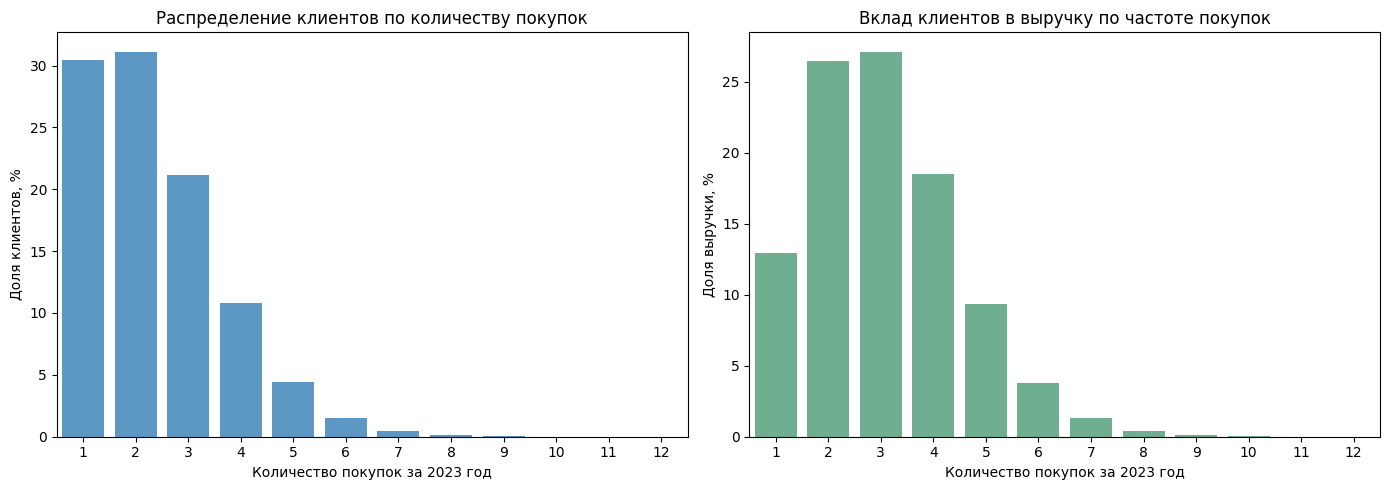

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=frequency_profile,
    x='frequency',
    y='clients_pct',
    ax=axes[0],
    color='#4C9BD6'
)
axes[0].set_title('Распределение клиентов по количеству покупок')
axes[0].set_xlabel('Количество покупок за 2023 год')
axes[0].set_ylabel('Доля клиентов, %')

sns.barplot(
    data=frequency_profile,
    x='frequency',
    y='revenue_pct',
    ax=axes[1],
    color='#65B891'
)
axes[1].set_title('Вклад клиентов в выручку по частоте покупок')
axes[1].set_xlabel('Количество покупок за 2023 год')
axes[1].set_ylabel('Доля выручки, %')

plt.tight_layout()
plt.show()

### Частота покупок и повторная активность клиентов

В 2023 году покупки совершили 869 966 уникальных клиентов. Повторную
покупку в течение года совершили 69,54% клиентов, однако интенсивность
повторных покупок остаётся невысокой: медианный клиент совершил только
две покупки.

Клиенты с одной покупкой составляют 30,46% клиентской базы, но формируют
только 12,95% выручки. Наибольшую ценность представляет массовая группа
клиентов с двумя–четырьмя покупками: она включает 63,09% клиентов и
обеспечивает 72,10% годовой выручки.

Клиенты с пятью и более покупками составляют только 6,46% базы и формируют
около 14,95% выручки. Следовательно, выручка не сосредоточена исключительно
в небольшой группе сверхактивных покупателей.

Основным резервом роста клиентской ценности является увеличение частоты
покупок в массовых сегментах: перевод клиентов с одной покупкой ко второй,
а клиентов с двумя покупками — к третьей и четвёртой. Для этого могут
использоваться персональные предложения после первой покупки, ограниченные
по времени промокоды, рекомендации сопутствующих товаров и коммуникации
в период ожидаемой следующей покупки.

### Кривая Парето

In [21]:
client_pareto = (
    client_profile
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)

client_pareto['cumulative_clients_pct'] = (
    (client_pareto.index + 1)
    / len(client_pareto)
    * 100
)

client_pareto['cumulative_revenue_pct'] = (
    client_pareto['revenue'].cumsum()
    / client_pareto['revenue'].sum()
    * 100
)

In [22]:
pareto_summary = pd.DataFrame({
    'top_clients_pct': [1, 5, 10, 20, 50],
    'revenue_pct': [
        client_pareto.loc[
            client_pareto['cumulative_clients_pct'] <= share,
            'revenue'
        ].sum() / client_pareto['revenue'].sum() * 100
        for share in [1, 5, 10, 20, 50]
    ]
})

pareto_summary

,top_clients_pct,revenue_pct
0,1,5.226339
1,5,19.514509
2,10,32.943653
3,20,53.007037
4,50,86.514842


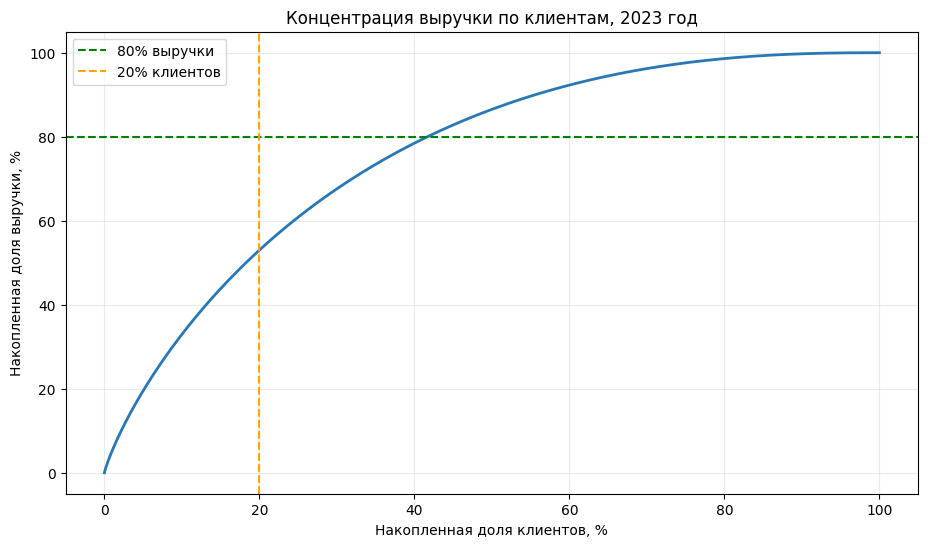

In [23]:
plt.figure(figsize=(11, 6))

plt.plot(
    client_pareto['cumulative_clients_pct'],
    client_pareto['cumulative_revenue_pct'],
    color='#2878B5',
    linewidth=2
)

plt.axhline(80, color='green', linestyle='--', label='80% выручки')
plt.axvline(20, color='orange', linestyle='--', label='20% клиентов')

plt.title('Концентрация выручки по клиентам, 2023 год')
plt.xlabel('Накопленная доля клиентов, %')
plt.ylabel('Накопленная доля выручки, %')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### 1. Расчет RFM - оценок

In [24]:
rfm = client_profile.copy()

# Чем меньше давность покупки, тем выше R
rfm['r_score'] = pd.qcut(
    rfm['recency_days'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Частота покупок имеет мало уникальных значений,
# поэтому задаём понятные бизнес-границы
rfm['f_score'] = np.select(
    [
        rfm['frequency'] == 1,
        rfm['frequency'] == 2,
        rfm['frequency'] == 3,
        rfm['frequency'] == 4,
        rfm['frequency'] >= 5
    ],
    [1, 2, 3, 4, 5]
)

# Денежная ценность клиента
rfm['m_score'] = pd.qcut(
    rfm['revenue'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['rf_score'] = (
    rfm['r_score'].astype(str) +
    rfm['f_score'].astype(str)
)

### 2. Присвоение RFM-сегментов

In [25]:
segment_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At risk',
    r'[1-2]5': 'Cannot lose',
    r'3[1-2]': 'About to sleep',
    r'33': 'Need attention',
    r'[3-4][4-5]': 'Loyal customers',
    r'41': 'Promising',
    r'51': 'New customers',
    r'[4-5][2-3]': 'Potential loyalists',
    r'5[4-5]': 'Champions'
}

rfm['rfm_segment'] = rfm['rf_score'].replace(
    segment_map,
    regex=True
)

### 3. Профиль сегментов

In [26]:
rfm_profile = (
    rfm
    .groupby('rfm_segment', as_index=False)
    .agg(
        clients=('client_id', 'count'),
        avg_recency_days=('recency_days', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_active_months=('active_months', 'mean'),
        avg_sale_amount=('avg_sale_amount', 'mean'),
        avg_revenue_per_client=('revenue', 'mean'),
        revenue=('revenue', 'sum')
    )
)

rfm_profile['clients_pct'] = (
    rfm_profile['clients']
    / rfm_profile['clients'].sum()
    * 100
)

rfm_profile['revenue_pct'] = (
    rfm_profile['revenue']
    / rfm_profile['revenue'].sum()
    * 100
)

rfm_profile = rfm_profile.sort_values(
    'revenue',
    ascending=False
)

rfm_profile.round(2)

,rfm_segment,clients,avg_recency_days,avg_frequency,avg_active_months,avg_sale_amount,avg_revenue_per_client,revenue,clients_pct,revenue_pct
8,Potential loyalists,194621,36.92,2.48,2.36,820796.77,2034753.10,3.960057e+11,22.37,23.65
4,Hibernating,279509,232.77,1.40,1.35,819198.89,1143347.16,3.195758e+11,32.13,19.08
5,Loyal customers,75582,75.33,4.52,3.88,821189.98,3710393.85,2.804390e+11,8.69,16.75
3,Champions,53976,15.95,4.65,4.06,820938.32,3815791.71,2.059612e+11,6.20,12.30
1,At risk,63459,187.75,3.25,2.80,825240.46,2680193.75,1.700824e+11,7.29,10.16
0,About to sleep,99279,105.96,1.59,1.56,815673.72,1298587.51,1.289225e+11,11.41,7.70
6,Need attention,43162,104.62,3.00,2.77,821762.42,2465287.27,1.064067e+11,4.96,6.35
9,Promising,30679,57.49,1.00,1.00,826105.31,826105.31,2.534408e+10,3.53,1.51
2,Cannot lose,5018,171.02,5.26,4.00,826922.88,4346387.73,2.181017e+10,0.58,1.30
7,New customers,24681,16.89,1.00,1.00,816910.41,816910.41,2.016217e+10,2.84,1.20


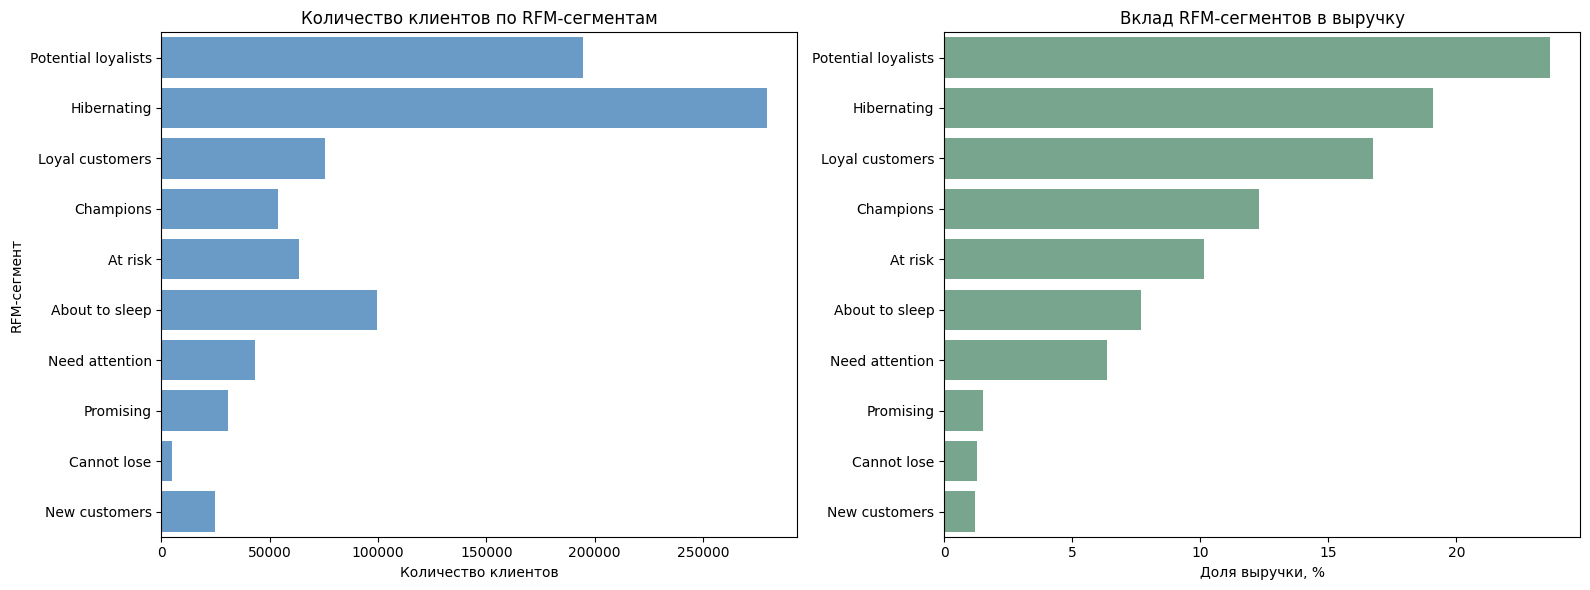

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=rfm_profile,
    x='clients',
    y='rfm_segment',
    ax=axes[0],
    color='#5B9BD5'
)
axes[0].set_title('Количество клиентов по RFM-сегментам')
axes[0].set_xlabel('Количество клиентов')
axes[0].set_ylabel('RFM-сегмент')

sns.barplot(
    data=rfm_profile,
    x='revenue_pct',
    y='rfm_segment',
    ax=axes[1],
    color='#70AD8E'
)
axes[1].set_title('Вклад RFM-сегментов в выручку')
axes[1].set_xlabel('Доля выручки, %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Итоги исследования клиентской базы за 2023 год

### Цель исследования

Цель исследования — определить основные резервы повышения ценности клиентской базы, выделить приоритетные клиентские сегменты и сформировать рекомендации по увеличению повторных покупок и LTV.

В качестве денежной оценки использована фактическая выручка клиента за 2023 год. Этот показатель является наблюдаемой годовой ценностью клиента, но не полноценным LTV, поскольку в данных отсутствуют себестоимость, маржинальность, расходы на привлечение и обслуживание клиентов, а также покупки за пределами исследуемого периода.

### Частота покупок

В 2023 году покупки совершили 869 966 уникальных клиентов.

- 30,46% клиентов совершили только одну покупку и сформировали 12,95% выручки.
- 69,54% клиентов совершили повторную покупку в течение года.
- Клиенты с двумя–тремя покупками составляют 52,27% базы и обеспечивают 53,60% выручки.
- Клиенты с двумя–четырьмя покупками составляют 63,09% базы и обеспечивают 72,10% выручки.
- Только 6,46% клиентов совершили пять и более покупок.

Несмотря на достаточно высокую долю повторных клиентов, интенсивность покупок остаётся невысокой: медианный клиент совершил только две покупки и был активен в течение двух месяцев.

Основной резерв роста клиентской ценности находится в переводе клиентов с одной покупки ко второй, а клиентов с двумя покупками — к третьей и четвёртой.

### Концентрация выручки

Распределение выручки не соответствует классическому правилу Парето 80/20: верхние 20% клиентов формируют приблизительно 53% выручки, а для получения 80% выручки требуется около 41% клиентской базы.

Следовательно, бизнес не зависит исключительно от небольшой группы крупнейших покупателей. Выручка распределена между достаточно широкой клиентской базой, поэтому работа только с наиболее ценными клиентами не обеспечит максимального эффекта.

Необходимо сочетать удержание лучших покупателей с массовой работой по увеличению частоты покупок среди клиентов со средней активностью.

### Результаты RFM-сегментации

Наиболее значимые сегменты клиентской базы:

| Сегмент | Доля клиентов | Доля выручки | Интерпретация |
|---|---:|---:|---|
| Potential loyalists | 22,37% | 23,65% | Недавние клиенты с потенциалом увеличения частоты покупок |
| Hibernating | 32,13% | 19,08% | Давно не совершали покупок и имеют низкую частоту |
| Loyal customers | 8,69% | 16,75% | Регулярные и сравнительно активные клиенты |
| Champions | 6,20% | 12,30% | Недавние, частые и наиболее ценные покупатели |
| At risk | 7,29% | 10,16% | Ранее активные клиенты, которые давно не покупали |
| About to sleep | 11,41% | 7,70% | Клиенты с низкой активностью и риском ухода |
| Need attention | 4,96% | 6,35% | Клиенты средней ценности, требующие дополнительного внимания |
| Promising | 3,53% | 1,51% | Недавние клиенты с одной покупкой |
| Cannot lose | 0,58% | 1,30% | Небольшая группа ранее наиболее активных клиентов |
| New customers | 2,84% | 1,20% | Новые клиенты, ещё не совершившие повторную покупку |

Сегменты `Champions` и `Loyal customers` вместе составляют 14,89% базы и формируют 29,05% выручки. Их необходимо удерживать и защищать от оттока.

Сегмент `Potential loyalists` является главным источником роста: он включает 22,37% клиентов и формирует 23,65% выручки. Эти клиенты покупали недавно и уже имеют опыт повторных покупок, поэтому их перевод в лояльные сегменты наиболее реалистичен.

Сегменты `At risk` и `Cannot lose` составляют 7,87% клиентской базы и формируют 11,46% выручки. Особенно важен сегмент `Cannot lose`, поскольку его средняя выручка на клиента является самой высокой среди всех сегментов.

Сегмент `Hibernating` является крупнейшим — 32,13% клиентской базы. Однако его массовая реактивация с помощью высоких скидок может оказаться экономически неэффективной, поэтому коммуникации следует проводить выборочно.

### Какие показатели необходимо увеличивать

#### 1. Частота покупок

Частота покупок является главным управляемым фактором роста клиентской ценности. Средний чек между RFM-сегментами отличается незначительно, тогда как средняя выручка на клиента заметно увеличивается вместе с количеством покупок.

Основная задача — стимулировать вторую, третью и четвёртую покупки.

#### 2. Количество активных месяцев

У наиболее ценных сегментов клиенты совершают покупки в течение большего числа месяцев. Поэтому необходимо не только увеличивать общее количество покупок, но и распределять их на более продолжительный период.

#### 3. Удержание клиентов

Следует снижать давность последней покупки и предотвращать переход клиентов из активных сегментов в `About to sleep`, `At risk` и `Hibernating`.

#### 4. Средний чек

Средний чек не следует выбирать главным направлением роста: его значение между сегментами отличается незначительно. Повышение среднего чека может применяться как дополнительный инструмент через комплекты товаров, сопутствующие рекомендации и порог бесплатной доставки.

#### 5. Размер скидки

Увеличивать скидки для всей клиентской базы не рекомендуется. Предыдущее исследование не выявило устойчивого положительного отклика количества продаж на более высокий уровень скидки. Скидки необходимо применять адресно и оценивать с помощью A/B-тестов.

## Рекомендации по работе с клиентской базой

### New customers и Promising

- запуск приветственной цепочки после первой покупки;
- персональное предложение на вторую покупку с ограниченным сроком действия;
- рекомендации сопутствующих товаров;
- напоминание через ожидаемый интервал до следующей покупки;
- контроль конверсии из первой покупки во вторую.

### Potential loyalists

- стимулирование третьей и четвёртой покупки;
- персональные рекомендации на основании истории заказов;
- накопительная программа лояльности;
- бонусы не за размер одной покупки, а за повторную активность;
- предложения комплектов и сопутствующих товаров.

### Champions и Loyal customers

- приоритетное обслуживание и персональные предложения;
- ранний доступ к акциям и новым товарам;
- программы лояльности с нефинансовыми преимуществами;
- кросс-продажи без чрезмерного увеличения скидки;
- контроль перехода клиентов в сегменты риска.

### About to sleep и Need attention

- автоматические коммуникации до наступления длительного перерыва;
- напоминания о ранее покупаемых товарах;
- ограниченные по времени персональные предложения;
- подбор товаров на основании предыдущих покупок;
- тестирование различных сроков и каналов коммуникации.

### At risk и Cannot lose

- персональные сценарии возврата;
- отдельная работа с наиболее ценными клиентами;
- выяснение возможных причин прекращения покупок;
- индивидуальные предложения, основанные на предыдущем поведении;
- ограничение затрат на возврат ожидаемой ценностью клиента.

### Hibernating

- недорогие массовые реактивационные кампании;
- выделение клиентов с исторически высокой выручкой;
- исключение многократных дорогостоящих коммуникаций без отклика;
- проведение контрольных экспериментов для оценки экономической эффективности возврата.

## Общий вывод

Главным резервом увеличения клиентской ценности является рост частоты повторных покупок и продолжительности активного периода клиента, а не общее повышение среднего чека или размера скидки.

Приоритетной группой являются `Potential loyalists`: она достаточно велика, покупала недавно и уже обеспечивает почти четверть выручки. Второе направление — удержание `Champions` и `Loyal customers`, формирующих 29,05% выручки. Для сегментов риска необходимы адресные сценарии возврата, а массовые скидки для неактивной базы применять не рекомендуется.

Для оценки полноценного LTV в дальнейшем необходимо дополнить данные сведениями о себестоимости, маржинальности, стоимости привлечения и удержания клиентов, а также увеличить горизонт наблюдения. Эффективность предложенных мероприятий следует проверять с помощью A/B-тестов по метрикам повторной покупки, частоты заказов, активных месяцев, удержания и выручки на клиента.